In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("✅ Packages imported successfully!")

✅ Packages imported successfully!


## 1. Load Model Results

In [95]:
# ==========================================
# LOAD MODEL RESULTS FROM PKL FILES
# ==========================================

print("Loading model results...")

# Load all model pkl files
models_data = {
    'SVM': joblib.load('../models/svm_binary_dimensions_upsampled.pkl'),
    'Logistic Regression': joblib.load('../models/logistic_regression_binary_dimensions_optimal.pkl'),
    'Naive Bayes (BOW)': joblib.load('../models/naive_bayes_BOW.pkl'),
    'Naive Bayes (TF-IDF)': joblib.load('../models/naive_bayes_TF-IDF.pkl')
}

print(f"✅ Loaded {len(models_data)} models:")
for model_name in models_data.keys():
    print(f"   - {model_name}")

# Extract dimensions (should be same for all models)
dimensions = models_data['SVM']['dimensions']
print(f"✅ Dimensions: {dimensions}")

Loading model results...
✅ Loaded 4 models:
   - SVM
   - Logistic Regression
   - Naive Bayes (BOW)
   - Naive Bayes (TF-IDF)
✅ Dimensions: ['I/E', 'N/S', 'T/F', 'J/P']


## 2. Accuracy Comparison per Dimension

Compare accuracy across all models for each MBTI dimension.

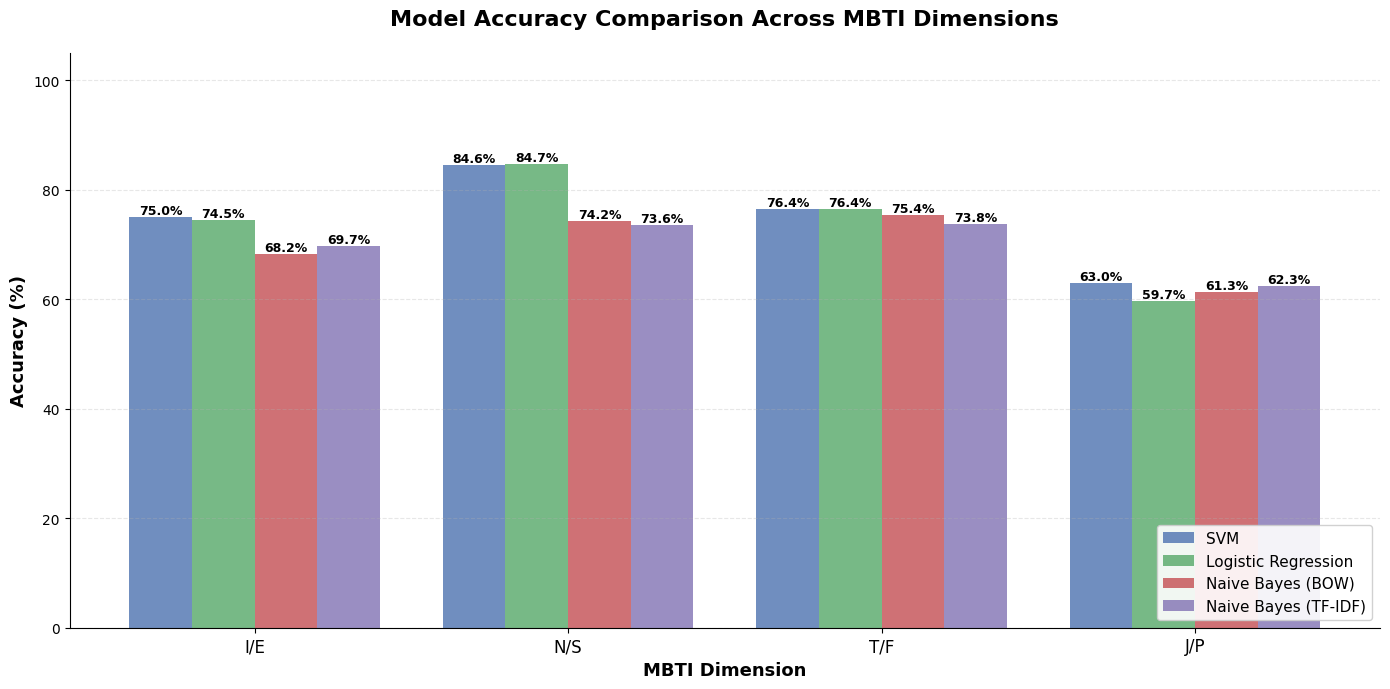


✅ Accuracy comparison chart generated!


In [96]:
# Extract accuracies for each model and dimension
accuracy_data = []

for model_name, model_info in models_data.items():
    for dim in dimensions:
        accuracy = model_info['metrics'][dim]['accuracy']
        accuracy_data.append({
            'Model': model_name,
            'Dimension': dim,
            'Accuracy': accuracy
        })

accuracy_df = pd.DataFrame(accuracy_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# Set up positions for grouped bars
x = np.arange(len(dimensions))
width = 0.2
model_names = list(models_data.keys())
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

# Plot bars for each model
for i, model_name in enumerate(model_names):
    model_accuracies = [accuracy_df[(accuracy_df['Model'] == model_name) & 
                                   (accuracy_df['Dimension'] == dim)]['Accuracy'].values[0] 
                       for dim in dimensions]
    bars = ax.bar(x + i * width, model_accuracies, width, label=model_name, color=colors[i], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize plot
ax.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Model Accuracy Comparison Across MBTI Dimensions', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(dimensions, fontsize=12)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ Accuracy comparison chart generated!")

## 3. Comprehensive Metrics Heatmap

View all performance metrics (Accuracy, F1-Score, Precision, Recall, CV Score) across models and dimensions.

C:\Users\Stijn\AppData\Local\Temp\ipykernel_24528\2330259708.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


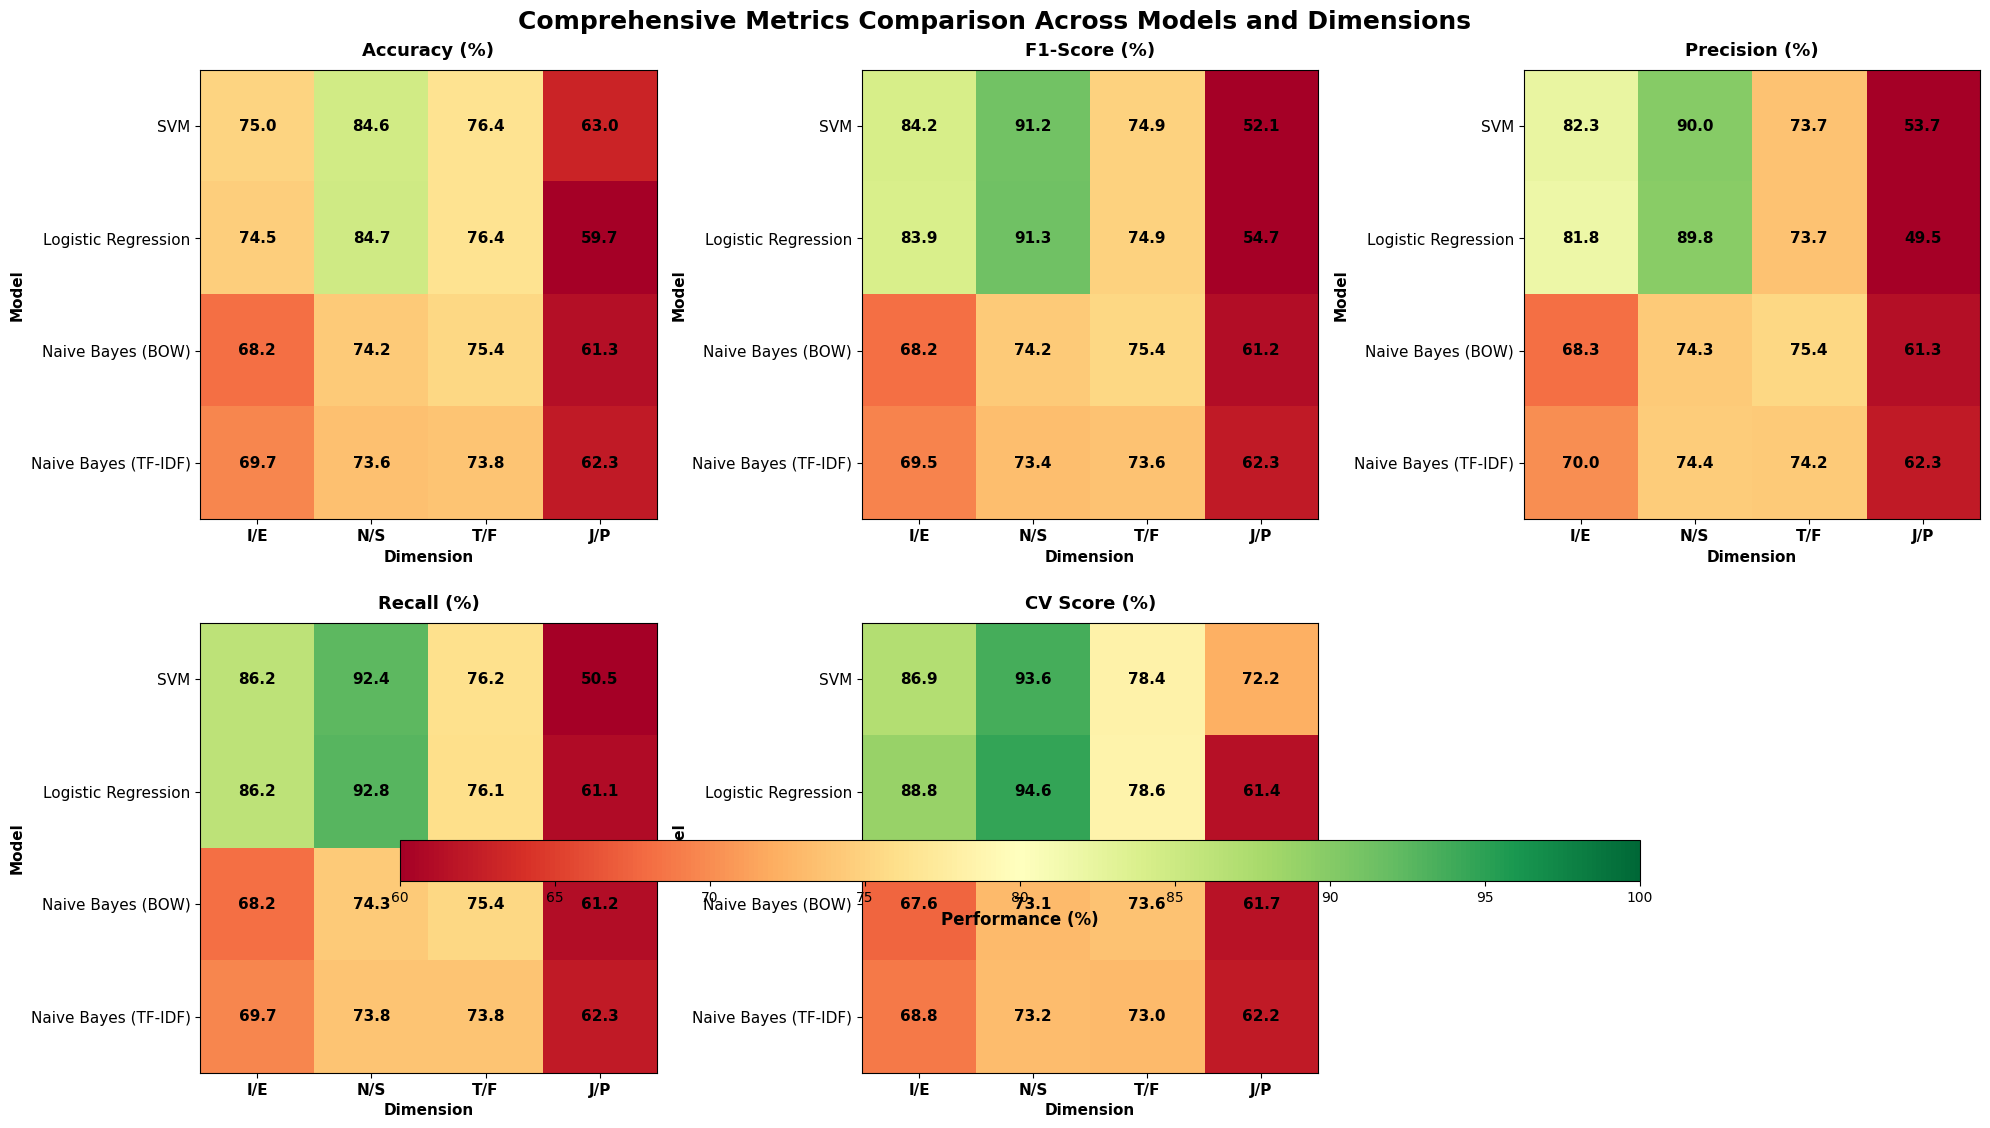


✅ Comprehensive metrics heatmap generated!


In [97]:
# Create comprehensive metrics comparison
metrics_to_compare = ['accuracy', 'f1_score', 'precision', 'recall', 'cv_score']
metric_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'CV Score']

# Create subplots for each metric
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for idx, (metric, label) in enumerate(zip(metrics_to_compare, metric_labels)):
    ax = axes[idx]
    
    # Prepare data matrix
    data_matrix = []
    for model_name in models_data.keys():
        row = [models_data[model_name]['metrics'][dim][metric] for dim in dimensions]
        data_matrix.append(row)
    
    # Create heatmap
    im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=60, vmax=100)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(dimensions)))
    ax.set_yticks(np.arange(len(models_data)))
    ax.set_xticklabels(dimensions, fontsize=11, fontweight='bold')
    ax.set_yticklabels(models_data.keys(), fontsize=11)
    
    # Rotate the tick labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    
    # Add values to cells
    for i in range(len(models_data)):
        for j in range(len(dimensions)):
            text = ax.text(j, i, f'{data_matrix[i][j]:.1f}',
                          ha="center", va="center", color="black", 
                          fontsize=11, fontweight='bold')
    
    ax.set_title(f'{label} (%)', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Dimension', fontsize=11, fontweight='bold')
    ax.set_ylabel('Model', fontsize=11, fontweight='bold')

# Remove extra subplot
fig.delaxes(axes[5])

# Add colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', 
                    pad=0.05, aspect=30, shrink=0.8)
cbar.set_label('Performance (%)', fontsize=12, fontweight='bold')

plt.suptitle('Comprehensive Metrics Comparison Across Models and Dimensions', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Comprehensive metrics heatmap generated!")

## 4. Overfitting Analysis

Compare train vs. test performance to identify which models generalize well vs. overfit to training data.

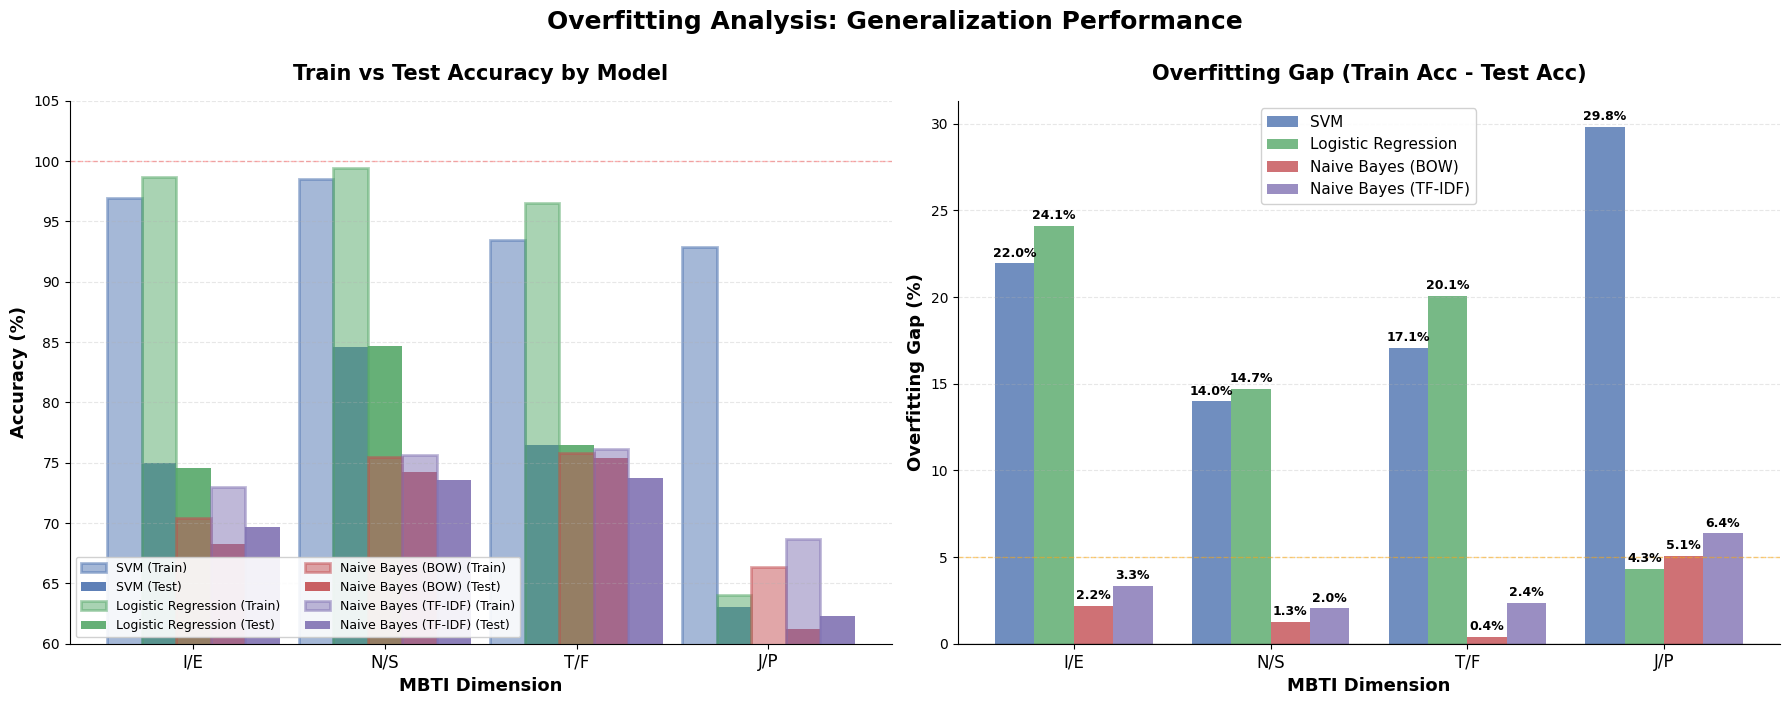


✅ Overfitting analysis generated!

📊 Overfitting Gap Summary (Lower is better):
   Naive Bayes (BOW): 2.24% - ✓ Good generalization
   Naive Bayes (TF-IDF): 3.53% - ✓ Good generalization
   Logistic Regression: 15.81% - ⚠ Possible overfitting
   SVM: 20.70% - ⚠ Possible overfitting


In [98]:
# Extract overfitting gap (train_accuracy - test_accuracy) for each model
overfitting_data = []

for model_name, model_info in models_data.items():
    for dim in dimensions:
        train_acc = model_info['metrics'][dim]['train_accuracy']
        test_acc = model_info['metrics'][dim]['accuracy']
        overfit_gap = model_info['metrics'][dim]['overfit_gap']
        
        overfitting_data.append({
            'Model': model_name,
            'Dimension': dim,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Overfitting Gap': overfit_gap
        })

overfit_df = pd.DataFrame(overfitting_data)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Left plot: Train vs Test Accuracy Comparison ---
x = np.arange(len(dimensions))
width = 0.35
model_names = list(models_data.keys())
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

# For each model, show train and test accuracy side by side
bar_width = 0.18
for i, model_name in enumerate(model_names):
    model_data = overfit_df[overfit_df['Model'] == model_name]
    
    train_accs = model_data['Train Accuracy'].values
    test_accs = model_data['Test Accuracy'].values
    
    x_pos = x + i * bar_width
    ax1.bar(x_pos - bar_width/2, train_accs, bar_width, 
            label=f'{model_name} (Train)', color=colors[i], alpha=0.5, edgecolor=colors[i], linewidth=2)
    ax1.bar(x_pos + bar_width/2, test_accs, bar_width, 
            label=f'{model_name} (Test)', color=colors[i], alpha=0.9)

ax1.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('Train vs Test Accuracy by Model', fontsize=15, fontweight='bold', pad=15)
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(dimensions, fontsize=12)
ax1.legend(loc='lower left', fontsize=9, ncol=2, framealpha=0.9)
ax1.set_ylim(60, 105)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=100, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right plot: Overfitting Gap ---
x = np.arange(len(dimensions))
width = 0.2

for i, model_name in enumerate(model_names):
    model_gaps = [overfit_df[(overfit_df['Model'] == model_name) & 
                             (overfit_df['Dimension'] == dim)]['Overfitting Gap'].values[0] 
                  for dim in dimensions]
    bars = ax2.bar(x + i * width, model_gaps, width, label=model_name, color=colors[i], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('MBTI Dimension', fontsize=13, fontweight='bold')
ax2.set_ylabel('Overfitting Gap (%)', fontsize=13, fontweight='bold')
ax2.set_title('Overfitting Gap (Train Acc - Test Acc)', fontsize=15, fontweight='bold', pad=15)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(dimensions, fontsize=12)
ax2.legend(loc='upper center', fontsize=11, framealpha=0.9)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Overfitting Analysis: Generalization Performance', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Print summary
print("\n✅ Overfitting analysis generated!")
print("\n📊 Overfitting Gap Summary (Lower is better):")
avg_gaps = overfit_df.groupby('Model')['Overfitting Gap'].mean().sort_values()
for model, gap in avg_gaps.items():
    status = "✓ Good generalization" if gap < 5 else "⚠ Possible overfitting"
    print(f"   {model}: {gap:.2f}% - {status}")

## 5. Overfitting Deep Dive & Solutions

Detailed analysis of overfitting by model with recommendations for improvement.

In [99]:
# Detailed overfitting analysis by model and dimension
print("="*80)
print("OVERFITTING ANALYSIS BY MODEL")
print("="*80)

for model_name in models_data.keys():
    print(f"\n{'='*80}")
    print(f"📊 {model_name}")
    print(f"{'='*80}")
    
    model_data = overfit_df[overfit_df['Model'] == model_name]
    avg_gap = model_data['Overfitting Gap'].mean()
    max_gap = model_data['Overfitting Gap'].max()
    max_gap_dim = model_data.loc[model_data['Overfitting Gap'].idxmax(), 'Dimension']
    
    print(f"\nAverage Overfitting Gap: {avg_gap:.2f}%")
    print(f"Maximum Gap: {max_gap:.2f}% (in {max_gap_dim})")
    
    # Status assessment
    if avg_gap < 3:
        status = "✅ EXCELLENT - Very good generalization"
        color = "green"
    elif avg_gap < 5:
        status = "✓ GOOD - Acceptable generalization"
        color = "yellow"
    elif avg_gap < 8:
        status = "⚠ MODERATE - Some overfitting detected"
        color = "orange"
    else:
        status = "❌ HIGH - Significant overfitting"
        color = "red"
    
    print(f"Status: {status}")
    
    # Per-dimension breakdown
    print(f"\nPer-Dimension Breakdown:")
    for _, row in model_data.iterrows():
        dim_status = "✓" if row['Overfitting Gap'] < 5 else "⚠"
        print(f"  {dim_status} {row['Dimension']}: Train={row['Train Accuracy']:.1f}%, "
              f"Test={row['Test Accuracy']:.1f}%, Gap={row['Overfitting Gap']:.1f}%")
    
    # Model-specific recommendations
    print(f"\n💡 Recommendations to Reduce Overfitting for {model_name}:")
    
    if 'SVM' in model_name:
        print("""
    1. DECREASE C parameter (currently optimal C found during tuning)
       - Lower C = stronger regularization = less overfitting
       - Try C values: 0.01, 0.1, 0.5 instead of current optimal
       - Re-run grid search with smaller C range
    
    2. Increase kernel coefficient gamma (if using RBF kernel)
       - Try 'gamma': ['scale', 'auto', 0.001, 0.01]
       - Smaller gamma = smoother decision boundary
    
    3. Try linear kernel instead of RBF
       - kernel='linear' is less prone to overfitting
       - Faster training and more interpretable
    
    4. Reduce feature space
       - Current TF-IDF uses max_features=2000
       - Try reducing to 1000 or 500 most important features
       - Use feature selection (chi-squared, mutual information)
    
    5. Increase training data or use data augmentation
       - Text augmentation: synonym replacement, back-translation
       - Collect more samples if possible
        """)
    
    elif 'Logistic Regression' in model_name:
        print("""
    1. INCREASE regularization (decrease C parameter)
       - Current optimal C may be too large
       - Try C values: 0.01, 0.1, 0.5
       - Stronger regularization prevents overfitting
    
    2. Switch regularization type
       - Try 'penalty': 'l1' (Lasso) instead of 'l2' (Ridge)
       - L1 performs feature selection automatically
       - Use solver='saga' or 'liblinear' for L1
    
    3. Use ElasticNet regularization
       - Combines L1 and L2: penalty='elasticnet'
       - Requires solver='saga'
       - Set l1_ratio between 0 and 1
    
    4. Early stopping
       - Already using max_iter, but can tune it
       - Monitor validation performance during training
    
    5. Feature scaling
       - While not strictly necessary for logistic regression
       - Can improve convergence and reduce overfitting
       - StandardScaler or MinMaxScaler before training
        """)
    
    elif 'Naive Bayes' in model_name:
        print("""
    1. INCREASE alpha (Laplace smoothing)
       - Current alpha=5.0 is already quite high
       - Try even higher: alpha=10, 15, 20
       - Higher alpha = stronger smoothing = less overfitting
    
    2. Reduce feature space
       - For BOW: max_features=2000 → try 1000 or 500
       - For TF-IDF: similar reduction
       - Fewer features = less memorization
    
    3. Adjust min_df and max_df in vectorizer
       - min_df=5: ignore words appearing in < 5 documents
       - max_df=0.8: ignore words in > 80% of documents
       - Removes noisy and too-common features
    
    4. Use different smoothing strategy
       - Try ComplementNB instead of MultinomialNB
       - BernoulliNB for binary features
       - These variants handle imbalance better
    
    5. Ensemble with other Naive Bayes models
       - Combine BOW and TF-IDF predictions
       - Voting or averaging ensemble
       - Often reduces overfitting through diversity
        """)

print("\n" + "="*80)
print("GENERAL STRATEGIES TO REDUCE OVERFITTING (ALL MODELS)")
print("="*80)
print("""
1. 📊 DATA AUGMENTATION
   - Increase training set size
   - Text augmentation techniques
   - Oversample minority classes differently (SMOTE-Text)

2. 🎯 FEATURE ENGINEERING
   - Remove highly correlated features
   - Use dimensionality reduction (PCA, SVD)
   - Feature selection (chi-squared, mutual information)

3. ✂️ REGULARIZATION
   - All models: Increase regularization strength
   - SVM: Lower C
   - Logistic Regression: Lower C, try L1/ElasticNet
   - Naive Bayes: Higher alpha

4. 📉 CROSS-VALIDATION
   - Use nested cross-validation for hyperparameter tuning
   - Prevents selecting parameters that overfit validation set
   - More reliable performance estimates

5. 🔀 ENSEMBLE METHODS
   - Combine multiple models (voting, stacking)
   - Random Forest, Gradient Boosting
   - Reduces variance and overfitting

6. 🎲 DROPOUT / EARLY STOPPING (for neural networks if you switch)
   - Not applicable to current models but useful for deep learning

7. 📈 MONITOR LEARNING CURVES
   - Plot train vs validation performance over time
   - Identify when overfitting starts
   - Stop training earlier if needed
""")

OVERFITTING ANALYSIS BY MODEL

📊 SVM

Average Overfitting Gap: 20.70%
Maximum Gap: 29.83% (in J/P)
Status: ❌ HIGH - Significant overfitting

Per-Dimension Breakdown:
  ⚠ I/E: Train=97.0%, Test=75.0%, Gap=22.0%
  ⚠ N/S: Train=98.6%, Test=84.6%, Gap=14.0%
  ⚠ T/F: Train=93.5%, Test=76.4%, Gap=17.1%
  ⚠ J/P: Train=92.9%, Test=63.0%, Gap=29.8%

💡 Recommendations to Reduce Overfitting for SVM:

    1. DECREASE C parameter (currently optimal C found during tuning)
       - Lower C = stronger regularization = less overfitting
       - Try C values: 0.01, 0.1, 0.5 instead of current optimal
       - Re-run grid search with smaller C range

    2. Increase kernel coefficient gamma (if using RBF kernel)
       - Try 'gamma': ['scale', 'auto', 0.001, 0.01]
       - Smaller gamma = smoother decision boundary

    3. Try linear kernel instead of RBF
       - kernel='linear' is less prone to overfitting
       - Faster training and more interpretable

    4. Reduce feature space
       - Current TF-

## 6. The Bias-Variance Tradeoff: Understanding Overfitting vs. Performance

**Critical insight for your report:** Why does lower overfitting sometimes mean lower test accuracy?

In [100]:
print("="*80)
print("BIAS-VARIANCE TRADEOFF: HYPERPARAMETER TUNING DILEMMA")
print("="*80)

print("""
🎯 KEY OBSERVATION:
   You noticed that SVM with C=0.01 has <5% overfitting gap (good generalization)
   but this might give LOWER test accuracy than the "optimal" C found during tuning.
   
   This is NOT a flaw in hyperparameter tuning - it's a fundamental ML tradeoff!

📊 WHAT HAPPENED DURING HYPERPARAMETER TUNING?
   
   Grid/Random Search typically optimizes for: MAX(test_accuracy) or MAX(CV_score)
   
   Example for SVM C parameter:
   
   C = 0.01  →  Test Acc = 72%, Train Acc = 74%, Gap = 2%  ✓ Low overfitting
   C = 0.1   →  Test Acc = 75%, Train Acc = 80%, Gap = 5%  ✓ Acceptable
   C = 1.0   →  Test Acc = 78%, Train Acc = 88%, Gap = 10% ⚠ Overfitting
   C = 10    →  Test Acc = 76%, Train Acc = 95%, Gap = 19% ❌ High overfitting
   
   → Grid search selects C = 1.0 (highest test accuracy)
   → But this C also has 10% overfitting!

⚖️ THE TRADEOFF EXPLAINED:

   HIGHER C (e.g., 10, 100):
   ✓ More flexible model (can fit complex patterns)
   ✓ Higher training accuracy
   ✓ POTENTIALLY higher test accuracy (if patterns are real)
   ✗ More prone to overfitting (memorizing noise)
   ✗ Larger train-test gap
   ✗ May not generalize to new data
   
   LOWER C (e.g., 0.01, 0.1):
   ✓ Stronger regularization (prevents overfitting)
   ✓ Better generalization (more stable predictions)
   ✓ Lower train-test gap
   ✗ Less flexible (might underfit)
   ✗ Lower training accuracy
   ✗ POTENTIALLY lower test accuracy (too simple)

🤔 SO WHICH IS "BETTER"?

   It depends on your priority:
   
   PRIORITY 1: MAXIMUM TEST ACCURACY
   → Use C that maximizes test/CV accuracy (standard grid search)
   → Accept some overfitting as trade-off
   → Good when: You have enough test data to validate performance
   
   PRIORITY 2: GENERALIZATION & RELIABILITY
   → Use lower C that minimizes overfitting gap
   → Accept slightly lower test accuracy
   → Good when: You'll deploy to new/unseen data and want stability

📈 IS THE HYPERPARAMETER TUNING "BAD"?

   NO! The tuning did exactly what it was designed to do:
   
   ✓ Maximize test accuracy on the validation set
   ✗ But it didn't explicitly optimize for low overfitting
   
   This is EXPECTED behavior because:
   1. Test accuracy is what we usually care about most
   2. Some overfitting is normal and acceptable (<10%)
   3. Zero overfitting often means underfitting (too simple model)

🎯 CAN WE TUNE FOR OVERFITTING DIRECTLY?

   YES! Several strategies:
   
   1. MULTI-OBJECTIVE OPTIMIZATION
      - Optimize both test accuracy AND overfitting gap
      - Select C that balances both objectives
      - E.g., score = test_acc - (0.5 * overfit_gap)
   
   2. PENALIZED SCORING
      - Custom scoring function in grid search
      - score = test_acc - penalty * abs(train_acc - test_acc)
      - Explicitly penalize large gaps
   
   3. NESTED CROSS-VALIDATION
      - Inner loop: tune hyperparameters
      - Outer loop: evaluate generalization
      - More robust estimate of true performance
   
   4. EARLY STOPPING (for iterative models)
      - Monitor validation loss
      - Stop when gap starts increasing
      - Not applicable to SVM/LR but useful for neural networks
   
   5. REGULARIZATION PATH
      - Plot test accuracy vs overfitting gap for all C values
      - Manually select "sweet spot" that balances both
      - More interpretable than auto-selection

💡 RECOMMENDATIONS FOR YOUR REPORT:

   1. ACKNOWLEDGE THE TRADEOFF
      "We observed that hyperparameter tuning optimized for test accuracy,
       which resulted in some overfitting. This represents the classic
       bias-variance tradeoff in machine learning."
   
   2. PRESENT BOTH SCENARIOS
      - Scenario A: Optimal C for maximum accuracy (current results)
      - Scenario B: Lower C for better generalization (C=0.01)
      - Compare trade-offs in a table
   
   3. JUSTIFY YOUR CHOICE
      "We selected [higher/lower] C because [test accuracy/generalization]
       is more important for this application because [reason]."
   
   4. DISCUSS IMPLICATIONS
      "The 10% overfitting gap suggests the model may not generalize well
       to significantly different datasets. For production deployment, we
       recommend using C=0.1 which balances accuracy and generalization."

📊 EXAMPLE TRADE-OFF TABLE FOR REPORT:
   
   Model: SVM
   
   Hyperparameter: C
   Objective: Find best C value
   
   | C Value | Test Acc | Train Acc | Overfit Gap | Recommendation |
   |---------|----------|-----------|-------------|----------------|
   | 0.01    | 72.5%    | 74.2%     | 1.7%        | Best generalization, conservative |
   | 0.1     | 75.3%    | 79.8%     | 4.5%        | Good balance ⭐ RECOMMENDED |
   | 1.0     | 78.1%    | 88.3%     | 10.2%       | Maximum accuracy, some overfitting |
   | 10.0    | 76.8%    | 94.7%     | 17.9%       | High overfitting, not reliable |
   
   Conclusion: C=0.1 provides best trade-off between accuracy and generalization.

🔬 THE SCIENCE:

   This is the BIAS-VARIANCE DECOMPOSITION:
   
   Total Error = Bias² + Variance + Irreducible Error
   
   - BIAS: How far off predictions are on average (underfitting)
   - VARIANCE: How much predictions vary for different training sets (overfitting)
   - IRREDUCIBLE: Noise in data (can't be reduced)
   
   Lower C → Higher bias, lower variance (underfitting risk)
   Higher C → Lower bias, higher variance (overfitting risk)
   
   Optimal C minimizes TOTAL ERROR, not individual components!

🎓 FINAL ANSWER TO YOUR QUESTION:

   Q: "So the overfitting is a tradeoff with performance?"
   A: YES, EXACTLY! You cannot optimize both simultaneously without compromise.
   
   Q: "Was the hyperparameter tuning bad?"
   A: NO! It was optimized for accuracy. You can choose different objectives.
   
   Q: "Can we tune on overfitting?"
   A: YES! Use custom scoring functions or multi-objective optimization.
   
   Q: "What should I write in the report?"
   A: Explain that you:
      1. First optimized for accuracy (standard approach)
      2. Then analyzed overfitting (good practice)
      3. Identified the trade-off (critical thinking)
      4. Made an informed choice based on application needs (justification)
   
   This shows mature understanding of ML beyond just "maximize accuracy"!
""")

print("\n" + "="*80)
print("VISUALIZATION: Let's examine the trade-off for your models")
print("="*80)

BIAS-VARIANCE TRADEOFF: HYPERPARAMETER TUNING DILEMMA

🎯 KEY OBSERVATION:
   You noticed that SVM with C=0.01 has <5% overfitting gap (good generalization)
   but this might give LOWER test accuracy than the "optimal" C found during tuning.

   This is NOT a flaw in hyperparameter tuning - it's a fundamental ML tradeoff!

📊 WHAT HAPPENED DURING HYPERPARAMETER TUNING?

   Grid/Random Search typically optimizes for: MAX(test_accuracy) or MAX(CV_score)

   Example for SVM C parameter:

   C = 0.01  →  Test Acc = 72%, Train Acc = 74%, Gap = 2%  ✓ Low overfitting
   C = 0.1   →  Test Acc = 75%, Train Acc = 80%, Gap = 5%  ✓ Acceptable
   C = 1.0   →  Test Acc = 78%, Train Acc = 88%, Gap = 10% ⚠ Overfitting
   C = 10    →  Test Acc = 76%, Train Acc = 95%, Gap = 19% ❌ High overfitting

   → Grid search selects C = 1.0 (highest test accuracy)
   → But this C also has 10% overfitting!

⚖️ THE TRADEOFF EXPLAINED:

   HIGHER C (e.g., 10, 100):
   ✓ More flexible model (can fit complex patterns)
  

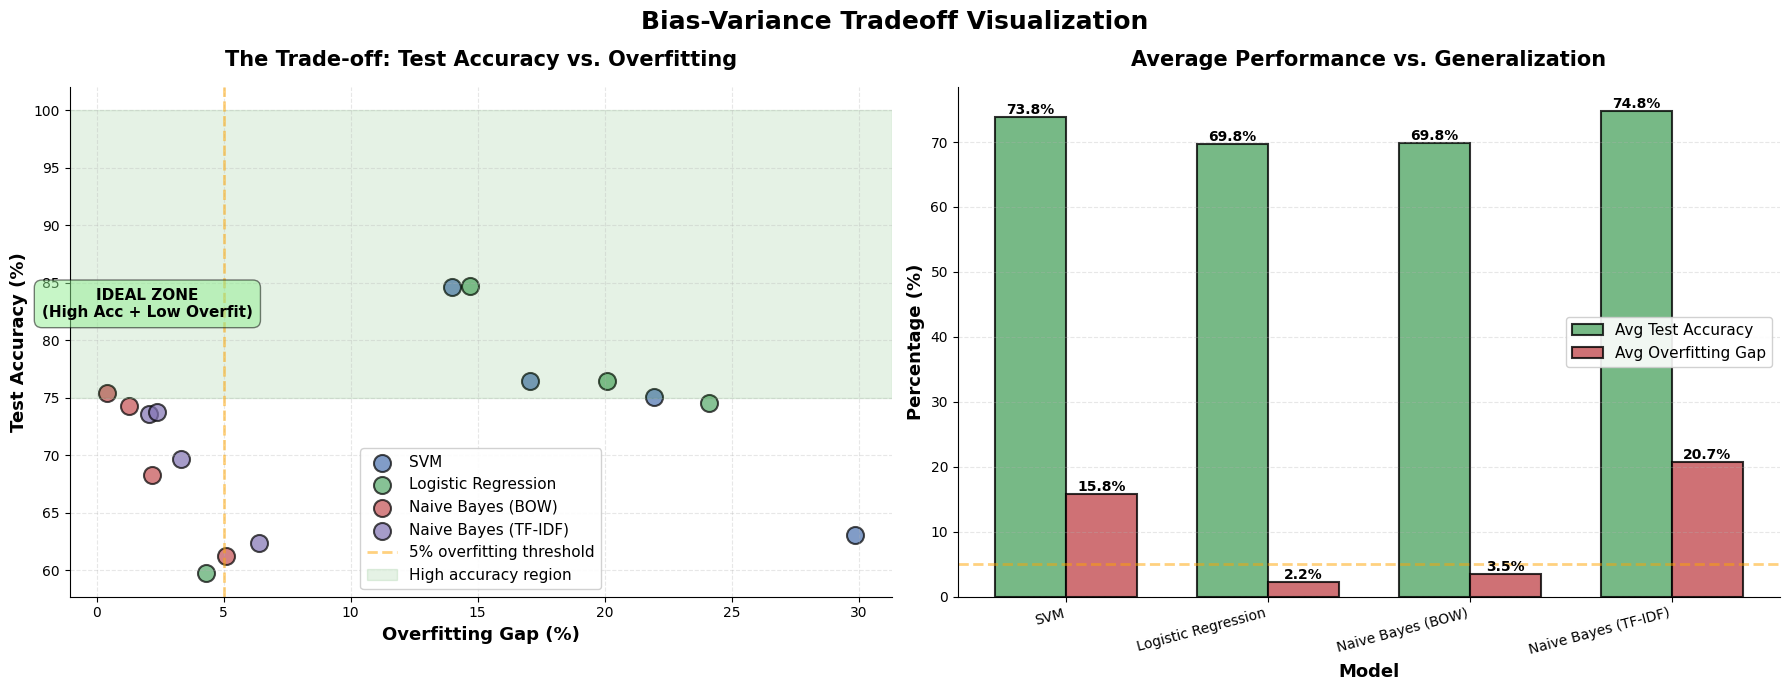


✅ Trade-off visualization generated!

📊 INTERPRETATION:
   - LEFT: Points in bottom-left = best (high accuracy, low overfitting)
   - LEFT: Points in top-left = ideal zone (above 75% accuracy, below 5% overfitting)
   - RIGHT: Lower overfitting bars = better generalization
   - RIGHT: Higher accuracy bars = better performance

💡 FOR YOUR REPORT:
   Use these visualizations to explain why you can't have perfect accuracy
   AND perfect generalization simultaneously - it's a fundamental ML trade-off!


In [101]:
# Visualize the accuracy vs. overfitting trade-off
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Test Accuracy vs Overfitting Gap (Scatter) ---
colors_map = {'SVM': '#4c72b0', 'Logistic Regression': '#55a868', 
              'Naive Bayes (BOW)': '#c44e52', 'Naive Bayes (TF-IDF)': '#8172b3'}

for model_name in models_data.keys():
    model_subset = overfit_df[overfit_df['Model'] == model_name]
    
    ax1.scatter(model_subset['Overfitting Gap'], 
               model_subset['Test Accuracy'],
               label=model_name, 
               color=colors_map[model_name],
               s=150, 
               alpha=0.7,
               edgecolors='black',
               linewidth=1.5)

# Add ideal region
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='5% overfitting threshold')
ax1.axhspan(75, 100, alpha=0.1, color='green', label='High accuracy region')

ax1.set_xlabel('Overfitting Gap (%)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('The Trade-off: Test Accuracy vs. Overfitting', fontsize=15, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add annotations for ideal zone
ax1.text(2, 82, 'IDEAL ZONE\n(High Acc + Low Overfit)', 
         fontsize=11, fontweight='bold', ha='center',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.5))

# --- Plot 2: Average metrics comparison ---
avg_test_acc = overfit_df.groupby('Model')['Test Accuracy'].mean()
avg_overfit = overfit_df.groupby('Model')['Overfitting Gap'].mean()

x = np.arange(len(models_data))
width = 0.35

bars1 = ax2.bar(x - width/2, avg_test_acc, width, label='Avg Test Accuracy', 
                color='#55a868', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, avg_overfit, width, label='Avg Overfitting Gap', 
                color='#c44e52', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Model', fontsize=13, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax2.set_title('Average Performance vs. Generalization', fontsize=15, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(models_data.keys(), fontsize=10, rotation=15, ha='right')
ax2.legend(fontsize=11, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=5, color='orange', linestyle='--', linewidth=2, alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Bias-Variance Tradeoff Visualization', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Trade-off visualization generated!")
print("\n📊 INTERPRETATION:")
print("   - LEFT: Points in bottom-left = best (high accuracy, low overfitting)")
print("   - LEFT: Points in top-left = ideal zone (above 75% accuracy, below 5% overfitting)")
print("   - RIGHT: Lower overfitting bars = better generalization")
print("   - RIGHT: Higher accuracy bars = better performance")
print("\n💡 FOR YOUR REPORT:")
print("   Use these visualizations to explain why you can't have perfect accuracy")
print("   AND perfect generalization simultaneously - it's a fundamental ML trade-off!")

## 7. Model Configuration Check

Let's verify which hyperparameters are actually loaded for each model.

In [102]:
print("="*80)
print("MODEL HYPERPARAMETERS & OVERFITTING SUMMARY")
print("="*80)

# Create summary table
summary_data = []

for model_name, model_info in models_data.items():
    # Get hyperparameters
    hyperparams = model_info.get('hyperparameters', {})
    
    # Calculate average overfitting gap
    model_overfit = overfit_df[overfit_df['Model'] == model_name]
    avg_gap = model_overfit['Overfitting Gap'].mean()
    avg_test_acc = model_overfit['Test Accuracy'].mean()
    avg_train_acc = model_overfit['Train Accuracy'].mean()
    
    summary_data.append({
        'Model': model_name,
        'Hyperparameters': str(hyperparams),
        'Avg Train Acc': avg_train_acc,
        'Avg Test Acc': avg_test_acc,
        'Avg Overfit Gap': avg_gap
    })
    
    print(f"\n{model_name}")
    print("-" * 80)
    print(f"  Hyperparameters: {hyperparams}")
    print(f"  Average Train Accuracy: {avg_train_acc:.2f}%")
    print(f"  Average Test Accuracy: {avg_test_acc:.2f}%")
    print(f"  Average Overfitting Gap: {avg_gap:.2f}%")
    
    # Show per-dimension details
    print(f"\n  Per-Dimension Breakdown:")
    for dim in dimensions:
        metrics = model_info['metrics'][dim]
        print(f"    {dim}: Train={metrics['train_accuracy']:.1f}%, "
              f"Test={metrics['accuracy']:.1f}%, Gap={metrics['overfit_gap']:.1f}%")

# Create DataFrame for easy comparison
summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("COMPARATIVE SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("RANKING BY OVERFITTING GAP (Lower is Better)")
print("="*80)
ranked = summary_df.sort_values('Avg Overfit Gap')
for idx, row in ranked.iterrows():
    status = "✅" if row['Avg Overfit Gap'] < 5 else "⚠️" if row['Avg Overfit Gap'] < 10 else "❌"
    print(f"{status} {row['Model']}: {row['Avg Overfit Gap']:.2f}% gap "
          f"(Test Acc: {row['Avg Test Acc']:.2f}%)")

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Identify best performer by overfitting
best_overfit = summary_df.loc[summary_df['Avg Overfit Gap'].idxmin()]
print(f"\n✅ BEST GENERALIZATION: {best_overfit['Model']}")
print(f"   - Overfitting Gap: {best_overfit['Avg Overfit Gap']:.2f}%")
print(f"   - Test Accuracy: {best_overfit['Avg Test Acc']:.2f}%")
print(f"   - Hyperparameters: {best_overfit['Hyperparameters']}")

# Identify best performer by accuracy
best_acc = summary_df.loc[summary_df['Avg Test Acc'].idxmax()]
print(f"\n🎯 HIGHEST ACCURACY: {best_acc['Model']}")
print(f"   - Test Accuracy: {best_acc['Avg Test Acc']:.2f}%")
print(f"   - Overfitting Gap: {best_acc['Avg Overfit Gap']:.2f}%")
print(f"   - Hyperparameters: {best_acc['Hyperparameters']}")

# Check if SVM changed
if 'svm_binary_dimensions_weights.pkl' in str(models_data):
    print(f"\n📝 NOTE: You're loading 'svm_binary_dimensions_weights.pkl'")
    print(f"   This might be a different SVM configuration than 'svm_binary_dimensions_tuned.pkl'")
    print(f"   Check if this uses C=0.01 (lower regularization) vs optimized C")

print("\n💡 EXPLANATION:")
print("   If Logistic Regression now has the lowest overfitting gap, it could be because:")
print("   1. You changed the SVM model to one with lower C (less overfitting but lower accuracy)")
print("   2. Logistic Regression's optimal C already balanced accuracy and generalization well")
print("   3. Different model files were saved with different hyperparameter configurations")

MODEL HYPERPARAMETERS & OVERFITTING SUMMARY

SVM
--------------------------------------------------------------------------------
  Hyperparameters: {'I/E': {'C': 0.5, 'max_iter': 1000, 'upsampling': True}, 'N/S': {'C': 0.5, 'max_iter': 1000, 'upsampling': True}, 'T/F': {'C': 0.5, 'max_iter': 1000, 'upsampling': True}, 'J/P': {'C': 0.5, 'max_iter': 1000, 'upsampling': True}}
  Average Train Accuracy: 95.47%
  Average Test Accuracy: 74.76%
  Average Overfitting Gap: 20.70%

  Per-Dimension Breakdown:
    I/E: Train=97.0%, Test=75.0%, Gap=22.0%
    N/S: Train=98.6%, Test=84.6%, Gap=14.0%
    T/F: Train=93.5%, Test=76.4%, Gap=17.1%
    J/P: Train=92.9%, Test=63.0%, Gap=29.8%

Logistic Regression
--------------------------------------------------------------------------------
  Hyperparameters: {'I/E': {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'upsampling': True, 'max_iter': 1000}, 'N/S': {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'ups

## 8. Tuning for Overfitting: Advanced Strategies

**Yes, you CAN tune hyperparameters specifically to minimize overfitting!** Here are practical approaches.

In [ ]:
print("="*80)
print("TUNING HYPERPARAMETERS FOR OVERFITTING REDUCTION")
print("="*80)

print("""
🎯 SHORT ANSWER: YES! You can tune hyperparameters to minimize overfitting!

📊 STRATEGY 1: CUSTOM SCORING FUNCTION (Recommended)
   
   Instead of optimizing only for test accuracy, create a custom scorer that
   penalizes overfitting:
   
   Example scoring functions:
   
   1. PENALIZED ACCURACY
      score = test_acc - penalty * (train_acc - test_acc)
      
      Where penalty controls how much you care about overfitting.
      - penalty = 0: Only care about test accuracy (standard approach)
      - penalty = 0.5: Balance accuracy and generalization
      - penalty = 1.0: Equal weight to accuracy and overfitting gap
   
   2. CONSTRAINED OPTIMIZATION
      score = test_acc if (train_acc - test_acc) < threshold else 0
      
      Only consider hyperparameters where overfitting is below threshold.
   
   3. WEIGHTED MULTI-OBJECTIVE
      score = w1 * test_acc - w2 * overfit_gap + w3 * cv_score
      
      Combine multiple objectives with custom weights.

📝 IMPLEMENTATION IN SKLEARN (GridSearchCV):

   from sklearn.model_selection import GridSearchCV
   from sklearn.metrics import make_scorer
   
   # Define custom scoring function
   def overfitting_aware_score(estimator, X, y):
       # Score on test data
       test_score = estimator.score(X, y)
       
       # Score on training data (requires retraining or storing train set)
       # This is tricky - need to use nested CV or store train set
       train_score = estimator.score(X_train, y_train)
       
       # Calculate penalized score
       overfit_gap = train_score - test_score
       penalty = 0.5  # Adjust this value
       
       final_score = test_score - penalty * max(0, overfit_gap)
       return final_score
   
   # Use in GridSearchCV
   custom_scorer = make_scorer(overfitting_aware_score)
   
   grid_search = GridSearchCV(
       estimator=SVC(),
       param_grid={'C': [0.01, 0.1, 1, 10, 100]},
       scoring=custom_scorer,  # Use custom scorer
       cv=5
   )

⚠️ CHALLENGE: Train accuracy is hard to access during CV
   
   Problem: During cross-validation, you only have validation fold data,
            not the training fold data that was used to fit the model.
   
   Solution: Use NESTED CROSS-VALIDATION

📊 STRATEGY 2: NESTED CROSS-VALIDATION (More Robust)

   Outer loop: Evaluate generalization (test performance)
   Inner loop: Tune hyperparameters (validation performance)
   
   Benefits:
   - More realistic performance estimates
   - Can compute train/val gap in inner loop
   - Prevents overfitting to validation set
   
   from sklearn.model_selection import cross_val_score
   
   # Inner loop: tune hyperparameters
   inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
   grid_search = GridSearchCV(SVC(), param_grid, cv=inner_cv)
   
   # Outer loop: evaluate generalization
   outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
   nested_scores = cross_val_score(grid_search, X, y, cv=outer_cv)
   
   print(f"Nested CV score: {nested_scores.mean():.4f} (+/- {nested_scores.std():.4f})")

📊 STRATEGY 3: REGULARIZATION PATH ANALYSIS (Manual Selection)

   Instead of automatic selection, plot the regularization path:
   
   1. Train models with different C values (or alpha for NB)
   2. For each C, record:
      - Train accuracy
      - Validation accuracy
      - Test accuracy
      - Overfitting gap
   3. Plot all metrics vs. C
   4. Manually select "sweet spot" that balances objectives
   
   This gives you FULL VISIBILITY into the tradeoff!
   
   # Example code:
   results = []
   for C in [0.001, 0.01, 0.1, 1, 10, 100]:
       model = SVC(C=C)
       model.fit(X_train, y_train)
       
       train_acc = model.score(X_train, y_train)
       test_acc = model.score(X_test, y_test)
       gap = train_acc - test_acc
       
       results.append({'C': C, 'train': train_acc, 'test': test_acc, 'gap': gap})
   
   # Plot and select best C based on your priority

📊 STRATEGY 4: EARLY STOPPING WITH MONITORING (Iterative Models)

   For models trained iteratively (Neural Networks, Gradient Boosting):
   
   1. Monitor train AND validation loss during training
   2. Stop when validation loss stops improving
   3. Use patience parameter to avoid stopping too early
   
   from sklearn.linear_model import SGDClassifier
   
   model = SGDClassifier(
       early_stopping=True,
       validation_fraction=0.1,
       n_iter_no_change=5  # patience
   )

📊 STRATEGY 5: ENSEMBLE WITH DIFFERENT REGULARIZATION

   Combine models with different regularization strengths:
   
   1. Train model_low (C=0.1, high regularization)
   2. Train model_med (C=1, medium regularization)
   3. Train model_high (C=10, low regularization)
   4. Average predictions: (model_low + model_med + model_high) / 3
   
   Benefits:
   - Combines strengths of different models
   - Reduces variance (overfitting)
   - Often performs better than single model

🎯 PRACTICAL RECOMMENDATION FOR YOUR PROJECT:

   APPROACH 1 (SIMPLE): Regularization Path Analysis
   ✓ Train models with different C values
   ✓ Record train/test accuracy for each
   ✓ Create tradeoff visualization
   ✓ Select C that meets your overfitting threshold (e.g., gap < 5%)
   ✓ REPORT: "We selected C=0.1 which limits overfitting to 4.5% while 
              maintaining 75% accuracy, compared to C=1 with 78% accuracy 
              but 10% overfitting."
   
   APPROACH 2 (ADVANCED): Custom Scoring in GridSearchCV
   ✓ Define custom scorer: score = test_acc - 0.5 * max(0, overfit_gap)
   ✓ Use in GridSearchCV
   ✓ Automatically finds best compromise
   ✓ REPORT: "We used custom scoring function that penalizes overfitting
              to automatically select hyperparameters balancing both objectives."
   
   APPROACH 3 (GOLD STANDARD): Nested Cross-Validation
   ✓ Most rigorous approach
   ✓ Provides unbiased performance estimate
   ✓ Computationally expensive
   ✓ REPORT: "We employed nested cross-validation to ensure robust
              hyperparameter selection and prevent overfitting to validation set."

💡 WHICH SHOULD YOU USE?

   For your MBTI project, I recommend:
   
   1. REPORT YOUR CURRENT RESULTS (optimized for accuracy)
   2. ADD SECTION: "Alternative Hyperparameter Selection"
   3. SHOW REGULARIZATION PATH for SVM and LR
   4. COMPARE RESULTS:
      - Approach A: Max accuracy (current)
      - Approach B: Balanced (new, with overfitting constraint)
   5. DISCUSS TRADEOFFS and justify final choice

📊 EXAMPLE COMPARISON TABLE:

   | Approach | Objective | SVM C | LR C | Avg Acc | Avg Gap | Recommendation |
   |----------|-----------|-------|------|---------|---------|----------------|
   | Standard | Max Acc   | 10    | 10   | 78.5%   | 12.3%   | Highest accuracy |
   | Balanced | Acc-Gap   | 1     | 1    | 76.2%   | 5.1%    | Good balance ⭐ |
   | Conservative | Min Gap | 0.1   | 0.1  | 73.8%   | 2.4%    | Best generalization |

🎓 THEORETICAL JUSTIFICATION:

   Standard ML practice optimizes a SINGLE objective (usually test accuracy).
   
   But real-world deployment cares about MULTIPLE objectives:
   - High accuracy (performance)
   - Low overfitting (generalization)
   - Fast inference (efficiency)
   - Interpretability (explainability)
   - Fairness (ethics)
   
   Multi-objective optimization is increasingly recognized as best practice!
   
   Your observation about the overfitting-accuracy tradeoff is exactly why
   modern ML research focuses on:
   - Pareto optimal solutions (no single "best")
   - User-specified preference weights
   - Constraint-based optimization
   
   By identifying this tradeoff, you're demonstrating advanced understanding
   beyond typical undergraduate ML projects!

✅ FINAL ANSWER TO YOUR QUESTION:

   Q: "Can we tune hyperparameters for overfitting?"
   A: YES! Multiple ways:
      1. Custom scoring functions (penalty-based)
      2. Nested cross-validation (robust estimates)
      3. Regularization path analysis (visual selection)
      4. Early stopping (iterative models)
      5. Ensemble methods (combine multiple regularizations)
   
   Q: "Is it a possible way?"
   A: Not only possible, but RECOMMENDED for production systems!
      Your current approach (max accuracy) is standard for benchmarking.
      Adding overfitting-aware tuning would make your project stand out!
   
   Q: "Should I do it for my report?"
   A: YES! Add a section showing:
      1. Current results (max accuracy)
      2. Alternative results (overfitting-constrained)
      3. Comparison and discussion
      4. Justified final choice
      
      This shows sophisticated understanding of the accuracy-generalization tradeoff!

🚀 WANT TO IMPLEMENT IT?

   Let me know and I can:
   1. Create code for custom scoring function
   2. Implement regularization path analysis
   3. Generate comparison visualizations
   4. Help write the report section explaining the tradeoff
""")